# 第 1 章实验：从标量到张量的自动微分引擎

这份 Notebook 是本章的教学主入口。请从上到下逐格运行：我们先手算链式法则，再观察标量 `Value` 如何记录动态图，随后升级到 NumPy `Tensor`，最后用 PyTorch、HVP 和 gradient checkpointing 实验验证结论。

完整可复用实现位于同目录的 `value.py`、`tensor.py` 与 `extensions.py`。

## 0. 环境与可复现性

固定随机种子，并从仓库根目录导入本章模块。所有数组使用 `float64`，让误差主要反映算法而不是低精度舍入。

In [1]:
from pathlib import Path
import importlib
import inspect
import sys

import numpy as np
import torch
from IPython.display import Image, display

REPO_ROOT = Path.cwd().resolve()

while not (REPO_ROOT / "code" / "ch01").exists():
    if REPO_ROOT.parent == REPO_ROOT:
        raise RuntimeError("请从本仓库内运行 Notebook")
    REPO_ROOT = REPO_ROOT.parent

sys.path.insert(0, str(REPO_ROOT))
ASSET_DIR = REPO_ROOT / "assets" / "ch01"
ASSET_DIR.mkdir(parents=True, exist_ok=True)

# IPython 会预载标准库 code.py；移除它，避免遮蔽仓库的 code/ package。
cached_code = sys.modules.get("code")
if cached_code is not None and not hasattr(cached_code, "__path__"):
    del sys.modules["code"]
    
importlib.invalidate_caches()

from code.ch01 import Tensor, Value
from code.ch01.extensions import (
    checkpoint_demo,
    finite_difference_hvp,
    gradient_check_curve,
    polynomial_grad,
)
from code.ch01.plot_ch01 import generate_all_plots

np.random.seed(7)
np.set_printoptions(precision=8, suppress=True)
print(f"NumPy {np.__version__} | PyTorch {torch.__version__} | root={REPO_ROOT.name}")

NumPy 1.26.4 | PyTorch 2.2.2 | root=ai-engineering-deepdive


## 1. 手算一条链

令 $u=ab+c$，$y=u^2$。

局部导数是 $\partial y/\partial u=2u$、$\partial u/\partial a=b$，所以 reverse-mode 从输出种子 $\bar y=1$ 出发，得到 $\bar a=2ub$。下面把手算结果和中心差分放在一起进行比较。

In [2]:
a, b, c = 2.0, -3.0, 10.0
u = a * b + c
y = u**2

analytic_da = 2 * u * b                                               # 手动根据求导法则计算对 a 的导数值
epsilon = 1e-6                                                        # 用于数值微分的微小扰动
f = lambda current_a: (current_a * b + c) ** 2                        # 定义一个函数 f(a) = (a * b + c)^2
numeric_da = (f(a + epsilon) - f(a - epsilon)) / (2 * epsilon)        # 使用中心差分法计算数值导数
print(f"u={u:.1f}, y={y:.1f}")
print(f"手算 dy/da={analytic_da:.8f}, 中心差分={numeric_da:.8f}")

u=4.0, y=16.0
手算 dy/da=-24.00000000, 中心差分=-24.00000000


## 2. 标量 Value：让每个结果记住自己如何产生

`Value` 的算子在前向时保存父节点和局部 `_backward` 闭包。`backward()` 只做两件事：先得到拓扑序，再逆序执行闭包。先直接查看真实实现中的核心方法。

In [3]:
print(inspect.getsource(Value.backward))

a_node = Value(2.0, label="a")
b_node = Value(-3.0, label="b")
c_node = Value(10.0, label="c")
y_node = (a_node * b_node + c_node) ** 2
y_node.backward()
print(f"y={y_node.data:.1f}, dy/da={a_node.grad:.8f}, dy/db={b_node.grad:.8f}, dy/dc={c_node.grad:.8f}")
print("拓扑节点数：", len(y_node.topological_order()))

    def backward(self, seed: float = 1.0, *, retain_grad: bool = False) -> None:
        """从当前输出反传。

        默认清空当前图的全部旧梯度。``retain_grad=True`` 只累加叶子节点梯度；
        中间节点仍会清空，防止旧的中间梯度被再次传播。
        """
        # 1. 构建整张计算图的拓扑顺序
        order = self.topological_order()

        # 2. 如果需要梯度累积，先暂存叶子节点旧梯度  
        #    为什么叶子节点可以累积梯度值？
        #    当我们需要“多次反向传播，把梯度叠加到同一个参数上”时，就需要对叶子节点累积梯度。
        #    最典型的场景就是梯度累积，例如单次 batch_size=4，8 次反向传播，累积到 batch_size=32
        #    然后进行一次参数更新，这8次累积的梯度值就会累加到叶子节点上    
        leaf_grads = (
            {node: node.grad for node in order if not node._prev} if retain_grad else {}
        ) 

        # 3. 把整张图当前 grad 全清零, 
        #    防止上一次 backward 留下的中间梯度，再次参与这一次传播。
        #    例如 u=2x, y=3u, 第一次反向传播后，y.grad=1, u.grad=3, x.grad=6
        #    如果不清零，下次再反向传播，y.grad 重新置 1，影响不大，
        #    但 u.grad += y.grad * 3=6, x.grad += u.grad * 2 = 18，计算错误了               
        for node in order:
            node.grad = 0.0

        # 4. 输出节点设置 seed，这相当于 dy/dy=1
 

## 3a. 菱形图：梯度必须累加

同一个节点可能沿多条路径影响输出。下面的 $y=x^2+x$ 形成菱形依赖：一条路径贡献 $2x$，另一条贡献 $1$。如果局部反向写成赋值而不是 `+=`，其中一条贡献会被覆盖。

In [4]:
x = Value(3.0, label="x")
squared = x * x
diamond_output = squared + x
diamond_output.backward()
print(f"x=3 时，自动微分得到 dy/dx={x.grad:.1f}；解析结果 2x+1={2 * 3 + 1}")

x=3 时，自动微分得到 dy/dx=7.0；解析结果 2x+1=7


## 3b. 可视化 + 手算一遍反向传播

数字对上了不代表直觉建立了。这里复现一个经典例子——两输入 `tanh` 神经元 $o=\tanh(x_1w_1+x_2w_2+b)$——先把它的表达式图画出来，再完全不依赖 `backward()`，只用链式法则手算每个节点的梯度，最后和自动结果对拍。

In [5]:
from code.ch01.viz import draw_graph

x1 = Value(2.0, label="x1")
x2 = Value(0.0, label="x2")
w1 = Value(-3.0, label="w1")
w2 = Value(1.0, label="w2")
b = Value(6.8813735870195432, label="b")

x1w1 = x1 * w1; x1w1.label = "x1*w1"
x2w2 = x2 * w2; x2w2.label = "x2*w2"
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = "x1w1+x2w2"
n = x1w1x2w2 + b; n.label = "n"
o = n.tanh(); o.label = "o"

fig_before = draw_graph(o)
fig_before.savefig(ASSET_DIR / "graph_before_backward.png", dpi=150)
print(f"o = tanh(n) = {o.data:.4f}，此时所有 grad 都还是 0")

o = tanh(n) = 0.7071，此时所有 grad 都还是 0


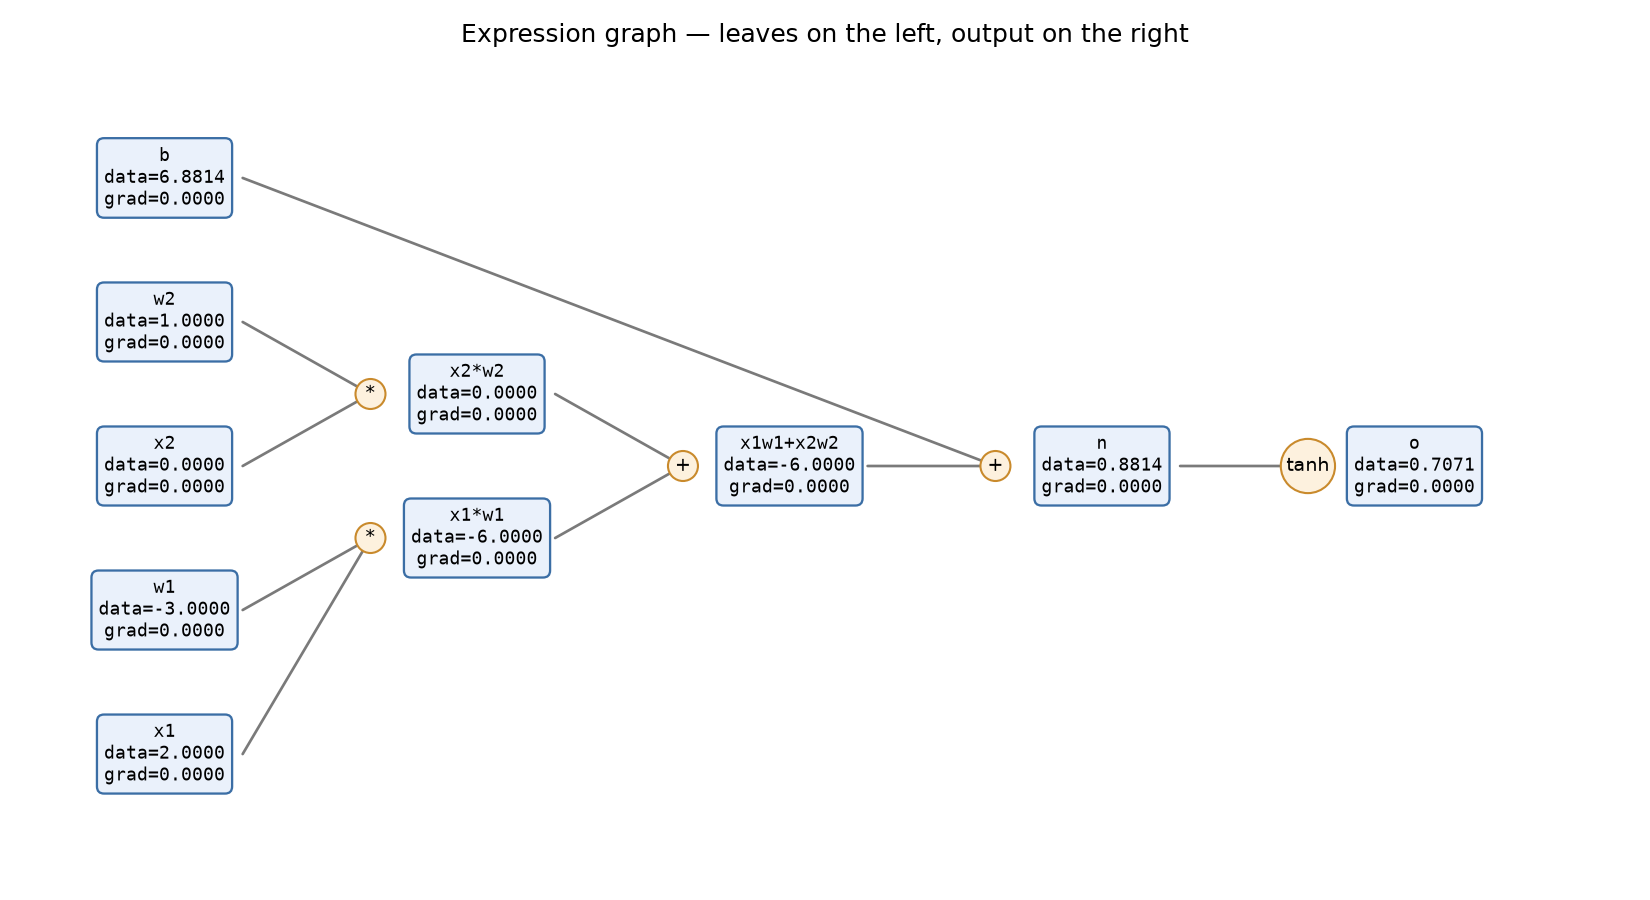

In [6]:
display(Image(filename=str(ASSET_DIR / "graph_before_backward.png"), width=900))

In [7]:
# 手算：从 o 往回一层层推链式法则，完全不调用 backward()。
do_dn = 1 - o.data ** 2              # d/dn tanh(n) = 1 - tanh(n)^2
dn_db = 1.0                          # n = x1w1x2w2 + b，对 b 的偏导是 1
dn_dx1w1x2w2 = 1.0                   # 对另一个加数同理
dx1w1x2w2_dx1w1 = 1.0                # x1w1x2w2 = x1w1 + x2w2
dx1w1x2w2_dx2w2 = 1.0
dx1w1_dw1 = x1.data                  # x1w1 = x1 * w1，对 w1 的偏导是 x1
dx1w1_dx1 = w1.data
dx2w2_dw2 = x2.data
dx2w2_dx2 = w2.data

manual_grad_w1 = do_dn * dn_dx1w1x2w2 * dx1w1x2w2_dx1w1 * dx1w1_dw1
manual_grad_x1 = do_dn * dn_dx1w1x2w2 * dx1w1x2w2_dx1w1 * dx1w1_dx1
manual_grad_w2 = do_dn * dn_dx1w1x2w2 * dx1w1x2w2_dx2w2 * dx2w2_dw2
manual_grad_x2 = do_dn * dn_dx1w1x2w2 * dx1w1x2w2_dx2w2 * dx2w2_dx2
manual_grad_b = do_dn * dn_db

o.backward()
for name, manual, node in [
    ("w1", manual_grad_w1, w1), ("x1", manual_grad_x1, x1),
    ("w2", manual_grad_w2, w2), ("x2", manual_grad_x2, x2),
    ("b", manual_grad_b, b),
]:
    print(f"{name}: 手算 grad={manual:.6f}  自动 backward grad={node.grad:.6f}")

w1: 手算 grad=1.000000  自动 backward grad=1.000000
x1: 手算 grad=-1.500000  自动 backward grad=-1.500000
w2: 手算 grad=0.000000  自动 backward grad=0.000000
x2: 手算 grad=0.500000  自动 backward grad=0.500000
b: 手算 grad=0.500000  自动 backward grad=0.500000


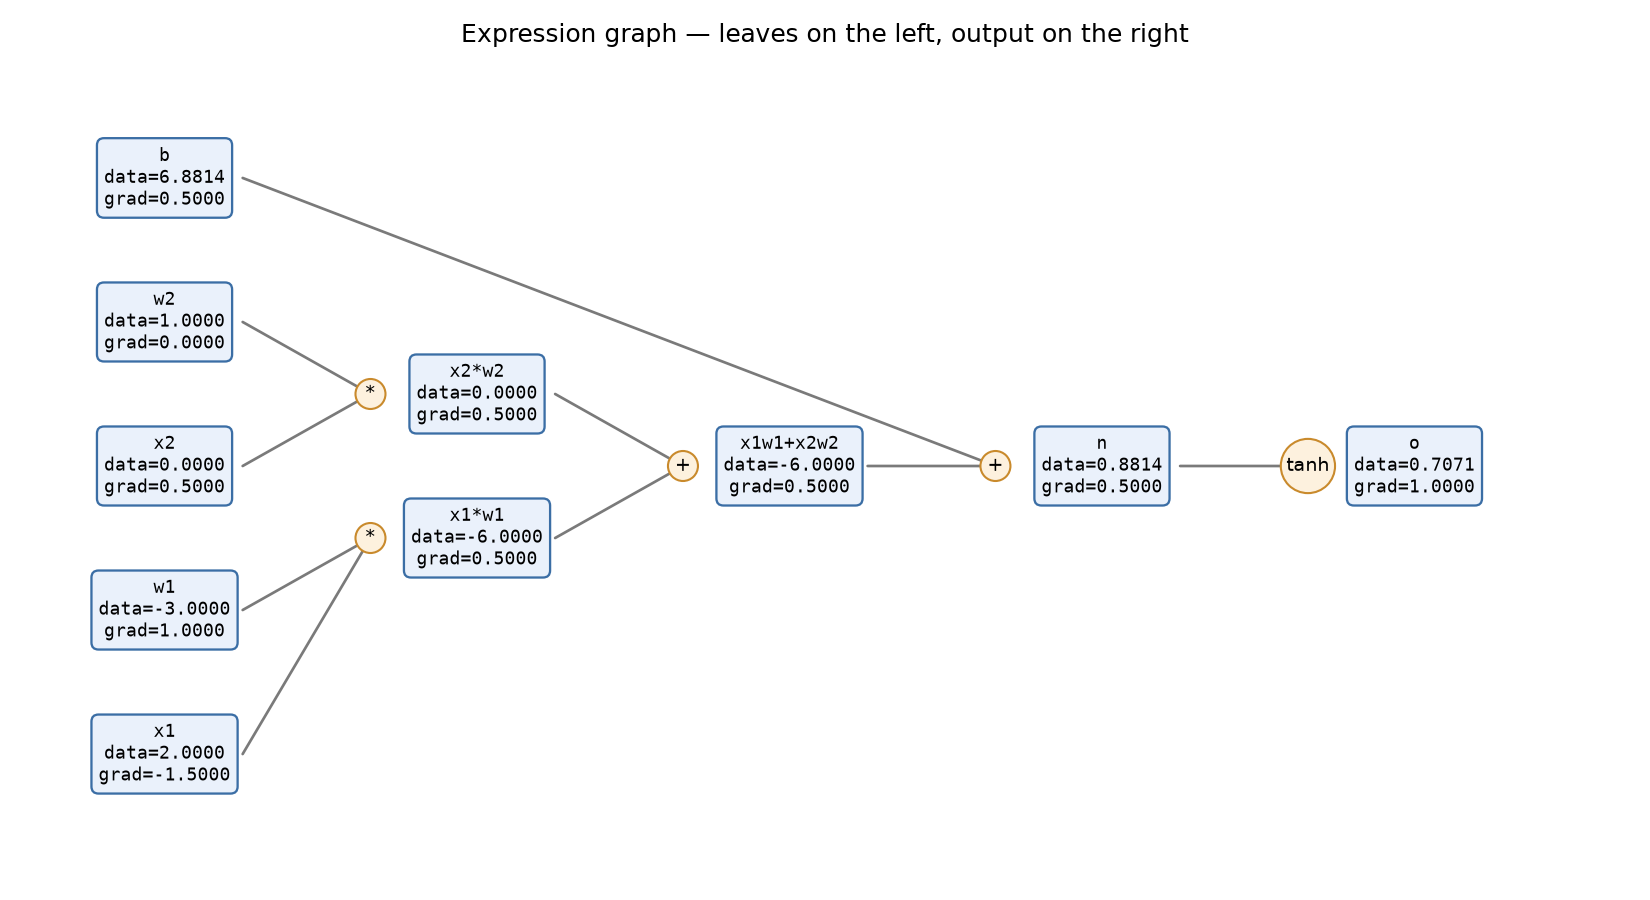

In [8]:
fig_after = draw_graph(o)
fig_after.savefig(ASSET_DIR / "graph_after_backward.png", dpi=150)
display(Image(filename=str(ASSET_DIR / "graph_after_backward.png"), width=900))

两张图唯一的区别是每个矩形里的 `grad` 数值——`backward()` 做的事情就是我们刚才手算的这一串链式法则乘积，只是它对任意深度的图自动完成，而且用 `+=` 正确处理了像 `n = x1w1x2w2 + b` 这样的分支合并（对照第 3 节的菱形图）。

## 4. Tensor 与广播：标量直觉遇到形状语义

张量图的拓扑机制没有变化，新增难点在 shape。前向广播把 `(3,)` 偏置扩成 `(2, 3)`；反向必须沿批次维求和，把梯度还原成 `(3,)`。`unbroadcast` 正是这一步的集中实现。

In [9]:
from code.ch01.tensor import unbroadcast
print(inspect.getsource(unbroadcast))

x_data = np.arange(6, dtype=np.float64).reshape(2, 3) / 10
bias_data = np.array([0.1, -0.2, 0.3])
x = Tensor(x_data, label="x")
bias = Tensor(bias_data, label="bias")
loss = (x * bias + bias).tanh().sum()
loss.backward()
print("loss =", float(loss.data))
print("x.grad shape =", x.grad.shape)
print("bias.grad shape =", bias.grad.shape, "value =", bias.grad)

def unbroadcast(grad: np.ndarray, shape: tuple[int, ...]) -> np.ndarray:
    """把广播后的梯度沿扩张维求和，还原成输入 ``shape``。"""

    grad = np.asarray(grad, dtype=np.float64)              # 转换为 NumPy 数组

    while grad.ndim > len(shape):                          # 如果 grad 维度比 shape 多，说明 grad 是广播后的结果，需要沿最前面的维度求和
        grad = grad.sum(axis=0)                            # 沿第一个维度求和

    for axis, size in enumerate(shape):                    # 如果 shape 中的某个维度是 1，而 grad 对应的维度不是 1，说明 grad 是广播后的结果，需要沿该维度求和
        if size == 1 and grad.shape[axis] != 1:            # 沿该维度求和
            grad = grad.sum(axis=axis, keepdims=True)      # keepdims=True 保持维度不变
    return grad.reshape(shape)                             # 显式地 reshape 成输入 shape，防止广播后维度不一致

loss = 0.5066304755603814
x.grad shape = (2, 3)
bias.grad shape = (3,) value = [2.26834147 2.34416387 2.28999457]


## 5. PyTorch 对拍：比较的是同一张数学计算图

框架对拍不是“看起来差不多”，而是在相同输入、相同 dtype、相同运算下比较输出与叶子梯度。这里用 `torch.autograd.grad` 作为独立基准。

In [10]:
torch_x = torch.tensor(x_data, requires_grad=True)
torch_bias = torch.tensor(bias_data, requires_grad=True)
torch_loss = torch.tanh(torch_x * torch_bias + torch_bias).sum()
expected_x, expected_bias = torch.autograd.grad(torch_loss, (torch_x, torch_bias))
print(f"loss 最大绝对误差：{abs(float(loss.data) - torch_loss.item()):.3e}")
print(f"x.grad 最大绝对误差：{np.max(np.abs(x.grad - expected_x.numpy())):.3e}")
print(f"bias.grad 最大绝对误差：{np.max(np.abs(bias.grad - expected_bias.numpy())):.3e}")

loss 最大绝对误差：1.110e-16
x.grad 最大绝对误差：0.000e+00
bias.grad 最大绝对误差：0.000e+00


## 6. 有限差分不是越小越好

中心差分有 $O(\epsilon^2)$ 截断误差，但当 $\epsilon$ 太小时，两次接近的浮点数相减会放大舍入误差。扫描步长会出现典型 U 形误差曲线。

本实验最佳 ε=5.484e-07，相对误差=2.354e-11


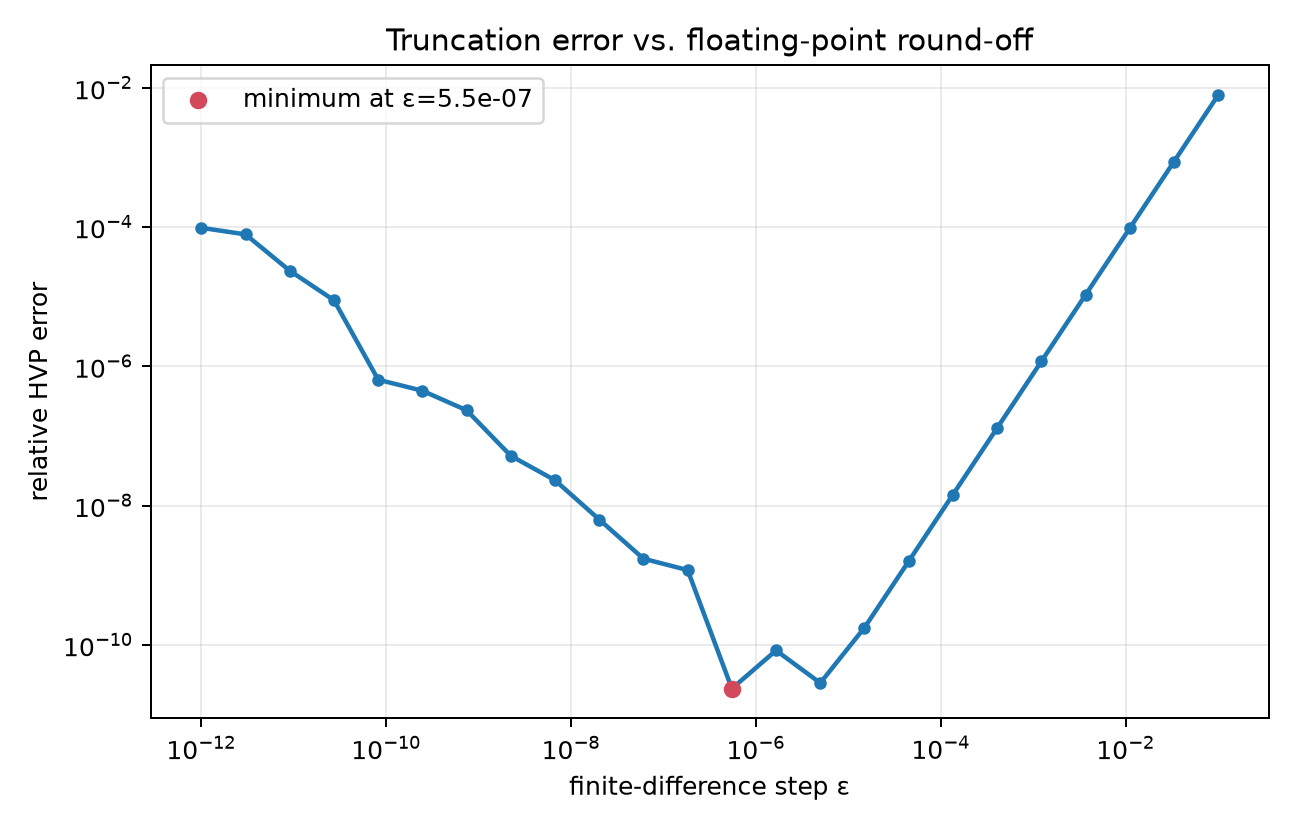

In [11]:
generated_paths = generate_all_plots(ASSET_DIR)
epsilons, errors = gradient_check_curve()
best = int(errors.argmin())
print(f"本实验最佳 ε={epsilons[best]:.3e}，相对误差={errors[best]:.3e}")
display(Image(filename=str(ASSET_DIR / "finite_difference_error.png"), width=720))

## 7. HVP：不显式构造 Hessian

Hessian-vector product（HVP）只问 $H(\theta)v$，不要求把 $n\times n$ Hessian 整体存下来。本教学引擎用 $[\nabla f(\theta+\epsilon v)-\nabla f(\theta-\epsilon v)]/(2\epsilon)$ 近似；

PyTorch 则通过可继续建图的一阶梯度给出精确基准。前者用于建立直觉，不能冒充生产中的精确高阶自动微分。

In [12]:
theta = np.array([0.4, -0.7, 1.2])
vector = np.array([1.0, -0.5, 0.25])
ours = finite_difference_hvp(polynomial_grad, theta, vector, epsilon=1e-5)

torch_theta = torch.tensor(theta, requires_grad=True)
torch_vector = torch.tensor(vector)
objective = (torch_theta**4 / 4 + torch.sin(torch_theta)).sum()
(first_grad,) = torch.autograd.grad(objective, torch_theta, create_graph=True)
(exact_hvp,) = torch.autograd.grad((first_grad * torch_vector).sum(), torch_theta)
print("自研引擎 + 中心差分：", ours)
print("PyTorch 精确 HVP：      ", exact_hvp.numpy())
print(f"最大绝对误差：{np.max(np.abs(ours - exact_hvp.numpy())):.3e}")

自研引擎 + 中心差分： [ 0.09058166 -1.05710884  0.84699023]
PyTorch 精确 HVP：       [ 0.09058166 -1.05710884  0.84699023]
最大绝对误差：1.054e-10


## 8. gradient checkpoint：用重计算换激活存储

普通反向保存块内每层激活；checkpoint 只保存边界输入，反向到达该块时重新执行一次前向。下面的代理指标统计“保存的激活元素数”和“块级前向调用次数”

depth | save-all elements | checkpoint elements | forward calls (plain/checkpoint)
    2 |                64 |                  32 | 1/2
    4 |               128 |                  32 | 1/2
    8 |               256 |                  32 | 1/2
   16 |               512 |                  32 | 1/2
输出最大差异： 0.0
梯度最大差异： 0.0


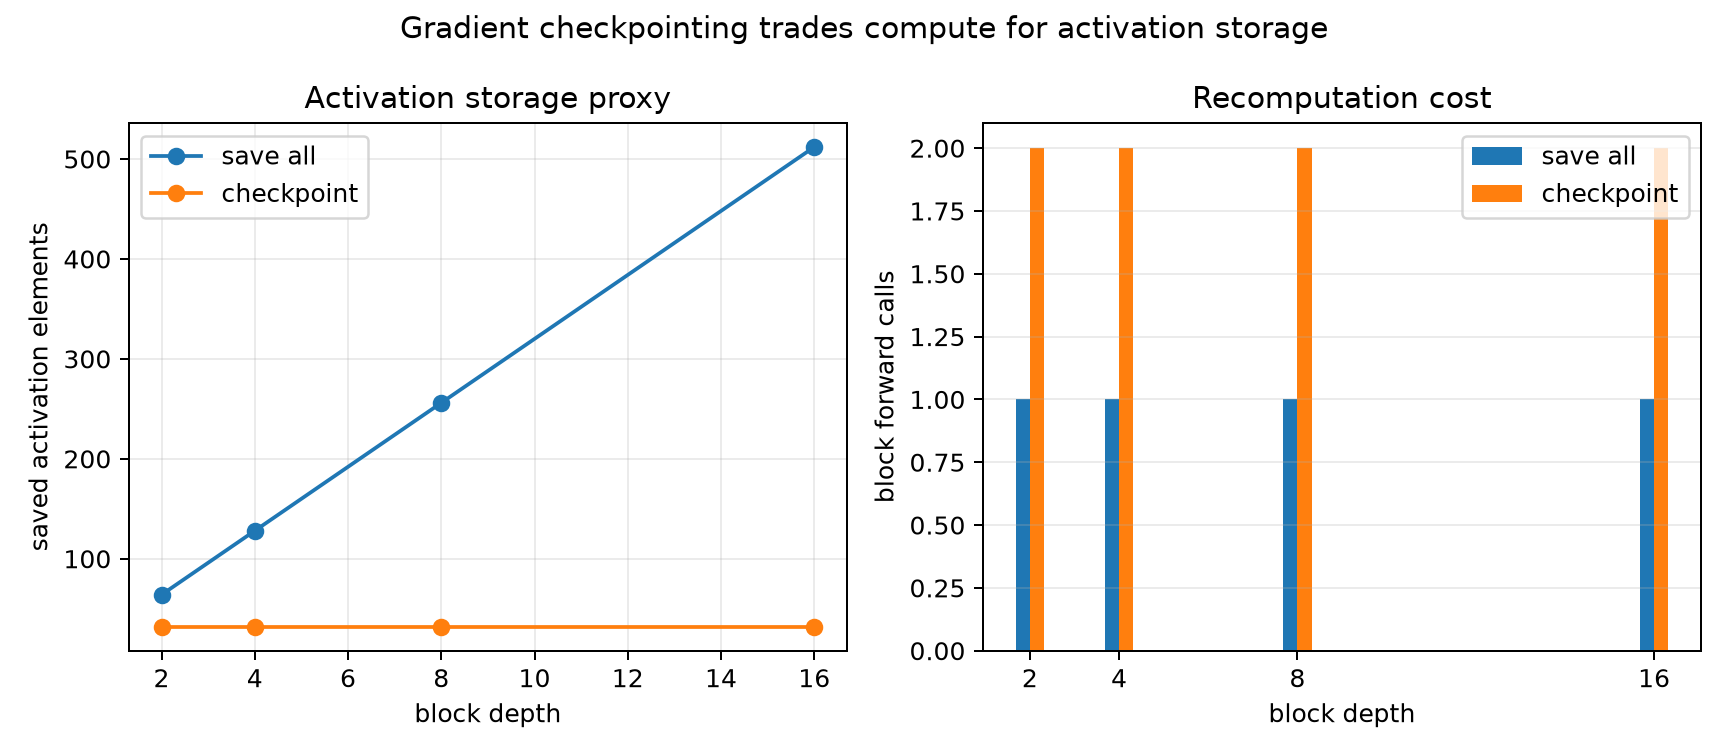

In [13]:
tradeoff = checkpoint_demo()
print("depth | save-all elements | checkpoint elements | forward calls (plain/checkpoint)")
for index, depth in enumerate(tradeoff["depths"]):
    print(
        f"{depth:>5} | {tradeoff['plain_saved'][index]:>17} | "
        f"{tradeoff['checkpoint_saved'][index]:>19} | "
        f"{tradeoff['plain_forward_calls'][index]}/{tradeoff['checkpoint_forward_calls'][index]}"
    )
print("输出最大差异：", np.max(np.abs(tradeoff["plain_output"] - tradeoff["checkpoint_output"])))
print("梯度最大差异：", np.max(np.abs(tradeoff["plain_grad"] - tradeoff["checkpoint_grad"])))
display(Image(filename=str(ASSET_DIR / "checkpoint_tradeoff.png"), width=900))

为了简化实现难度，我们此处演示的 checkpoint 仅保存输入，丢弃中间所有计算图，而在反向计算过程中，重新完整计算整个图，因此在左侧图中，checkpoint 保存的激活元素数量仅为输入数据的元素数，不随 depth 变化，而非 checkpoint 实现方式则呈增长趋势，我们此处构建的虚拟计算图，每层实际完全一致，因此增长也是完美线性增长。而右侧展示的是前向计算过程被运行的次数，由于 checkpoint 丢弃的所有计算图，所以在反向传播时需要先重构，所以相当于多计算了一次。

## 9. 从引擎到网络：训练一个真正会学习的小模型

前面的每个实验都在回答"梯度算得对不对"。这里换一个问题："这台引擎能不能真的训练出点什么？"——用 `Neuron`/`Layer`/`MLP`（同样建立在 `Value` 之上，没有引入任何新的自动微分机制）在一个 4 样本的玩具二分类数据集上跑一遍完整的梯度下降。

In [22]:
from code.ch01.mlp import TOY_INPUTS, TOY_TARGETS, train_toy_mlp

result = train_toy_mlp(steps=60, learning_rate=0.05, seed=42)
print("训练前预测：", [f"{p:.3f}" for p in result["initial_predictions"]])
print("训练后预测：", [f"{p:.3f}" for p in result["final_predictions"]])
print("目标标签：   ", result["targets"])
print(f"loss[0]={result['loss_history'][0]:.4f} -> loss[-1]={result['loss_history'][-1]:.6f}")

训练前预测： ['0.938', '0.768', '0.618', '0.840']
训练后预测： ['1.053', '-0.942', '-0.989', '0.889']
目标标签：    [1.0, -1.0, -1.0, 1.0]
loss[0]=1.4430 -> loss[-1]=0.004986


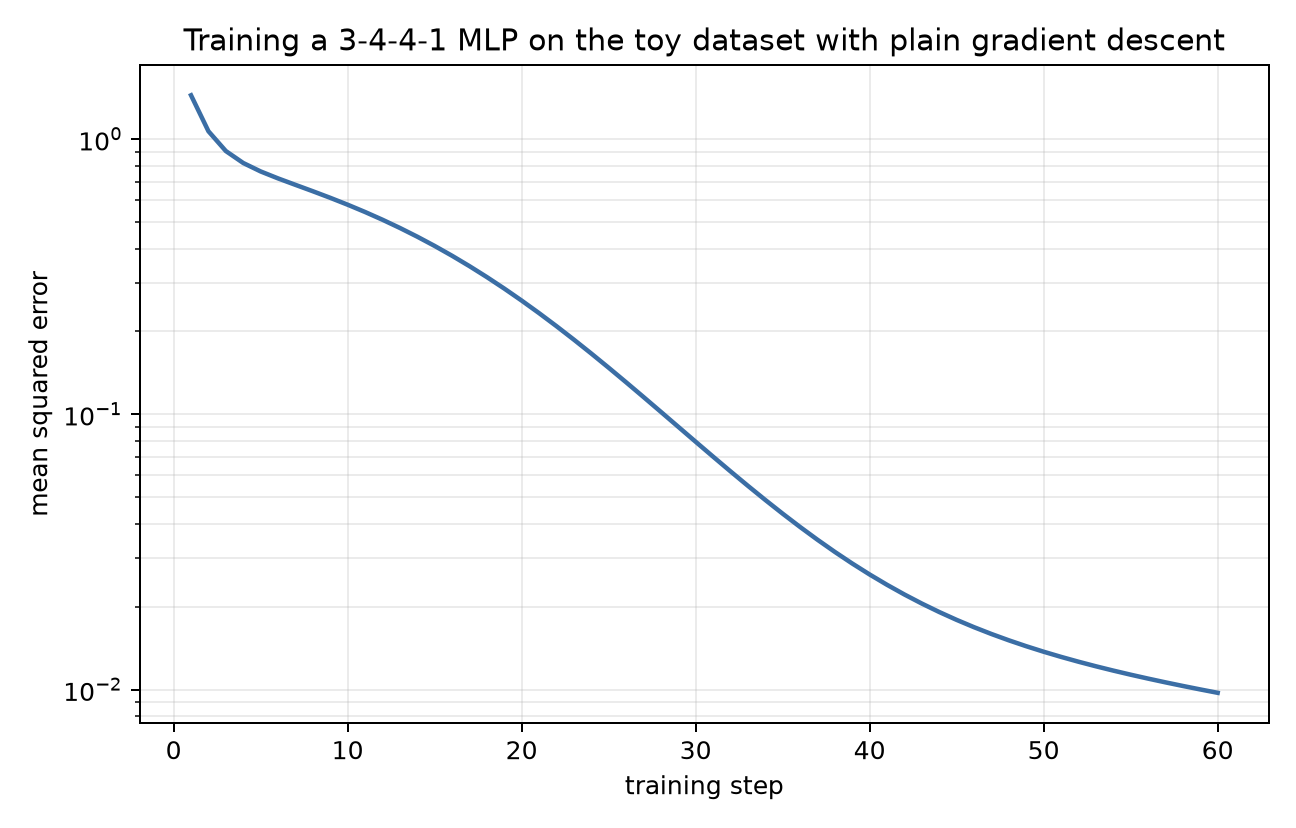

In [23]:
display(Image(filename=str(ASSET_DIR / "mlp_training_loss.png"), width=720))

模型 3-4-4-1 一共 `(3*4+4) + (4*4+4) + (4*1+1) = 41` 个参数，每一步都调用同一个 `Value.backward()`——训练一个网络在机制上和第 1 节里对 $y=(ab+c)^2$ 求导没有任何区别，只是图更大、参数更多、循环了 60 次。这正是本章想传达的核心直觉：backprop 不是"另一种算法"，是同一个 reverse-mode AD 引擎被套在了更大的图上。

## 10. 结论与改造建议

- reverse-mode 的核心是局部导数、逆拓扑序与梯度累加，而不是某个框架 API。
- 从标量升级到张量后，广播回收和上游梯度 shape 成为正确性的关键。
- 数值梯度适合检查一阶实现或近似 HVP，但步长存在精度权衡。
- checkpoint 不会凭空省成本：少存激活的代价是反向阶段重算前向。
- 一个能训练的神经网络和第 1 节的三行手算表达式，用的是完全同一套机制。

建议先修改一个算子的局部导数，观察哪项 pytest 和哪段对拍输出会失败；再为 `Tensor` 增加 `log()`，按照“先写对拍测试、再实现”的顺序完成。想更直观地感受"梯度覆盖"这个坑，可以把 `mlp.py` 里 `Value.__add__`（在 `value.py` 中）的 `+=` 临时改成 `=`，重新跑一遍训练循环，观察 loss 曲线会怎样偏离本节的结果——记得改完测试再改回来。